# Sephora Data - Product EDA

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
#Load dataset
product_data = pd.read_csv("product_info.csv",encoding="iso-8859-1")

In [7]:
product_data.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320.0,3.6364,11,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827.0,4.1538,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253.0,4.2500,16,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018.0,4.4762,21,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691.0,3.2308,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [8]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   object 
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   float64
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   object 
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6895 non-null   object 
 10  variation_desc      1251 non-null   object 
 11  ingredients         7550 non-null   object 
 12  price_usd           8492 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      272 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

In [9]:
product_data.describe()

,loves_count,rating,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,child_count,child_max_price,child_min_price
count,8.494000e+03,8216.000000,8492.000000,451.000000,272.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,2754.000000,2752.000000
mean,2.917798e+04,4.232340,51.646211,91.168537,20.059301,0.070285,0.071698,0.219214,0.073581,1.648575,53.764789,39.668103
std,6.609266e+04,3.467640,53.666909,79.195631,24.299052,0.255642,0.258002,0.413738,0.261104,5.513436,58.759532,38.699289
min,0.000000e+00,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
25%,3.756500e+03,3.981725,25.000000,45.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,19.000000
50%,9.876500e+03,4.289550,35.000000,67.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,28.000000
75%,2.684125e+04,4.530725,58.000000,108.500000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,59.000000,42.000000
max,1.401068e+06,315.000000,1900.000000,617.000000,320.000000,1.000000,1.000000,1.000000,1.000000,105.000000,570.000000,400.000000


In [34]:
# Unique values count for each column
unique_values_count = product_data.nunique()
print("Number of Unique Values for Each Column:")
print(unique_values_count)

Number of Unique Values for Each Column:
product_id            8494
product_name          8415
brand_id               305
brand_name             305
loves_count           7436
rating                4394
reviews               1557
size                  2056
variation_type           8
variation_value       2729
variation_desc         936
ingredients           6540
price_usd              298
value_price_usd        174
sale_price_usd          89
limited_edition          2
new                      2
online_only              2
out_of_stock             2
sephora_exclusive        3
highlights            4418
primary_category        11
secondary_category      43
tertiary_category      119
child_count             55
child_max_price        222
child_min_price        208
dtype: int64


In [11]:
missing_values = product_data.isnull().sum()
print("\nMissing Values:\n")
print(missing_values[missing_values > 0])


Missing Values:

rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1599
variation_desc        7243
ingredients            944
price_usd                2
value_price_usd       8043
sale_price_usd        8222
sephora_exclusive        1
highlights            2206
secondary_category       8
tertiary_category      990
child_max_price       5740
child_min_price       5742
dtype: int64


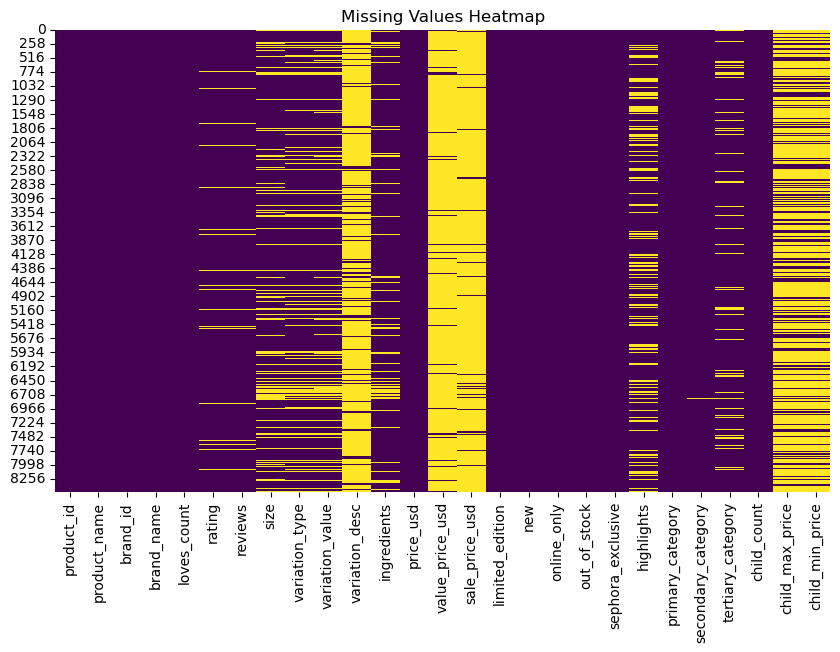

In [14]:
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(product_data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [13]:
# Check for duplicate rows
duplicates = product_data.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)


Number of Duplicate Rows: 0


In [15]:
# Categorical and numerical column separation
categorical_cols = product_data.select_dtypes(include=['object']).columns
numerical_cols = product_data.select_dtypes(include=['number']).columns
print("\nCategorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())


Categorical Columns: ['product_id', 'product_name', 'brand_id', 'brand_name', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category']
Numerical Columns: ['loves_count', 'rating', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'child_count', 'child_max_price', 'child_min_price']


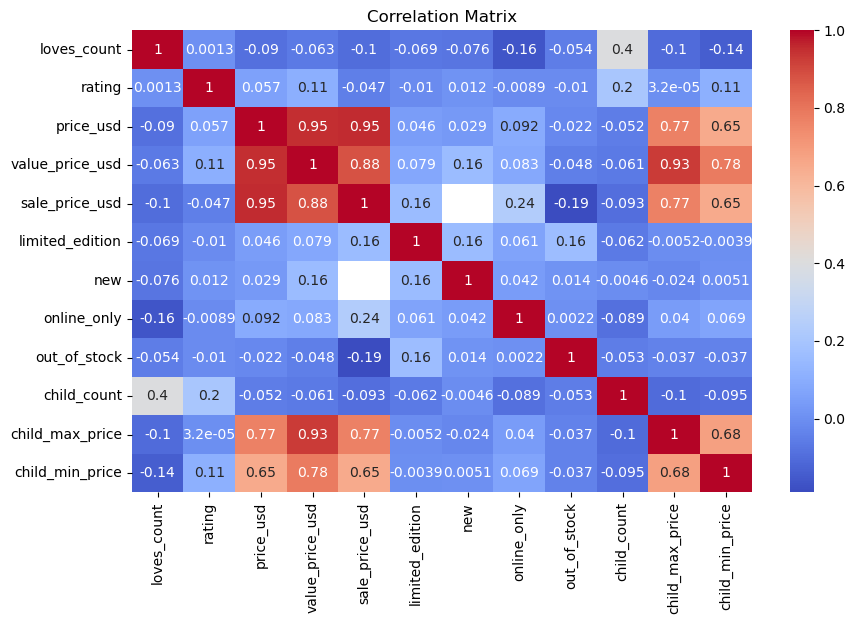

In [21]:
# Correlation matrix for numerical columns
plt.figure(figsize=(10, 6))
corr_matrix = product_data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [28]:
# Number of products for each brand
brand_product_count = product_data.groupby('brand_name')['product_id'].nunique().reset_index()
brand_product_count.columns = ['brand_name', 'product_count']
print("\nNumber of Products per Brand:")
print(brand_product_count)

top_10_brands = brand_product_count.sort_values(by='product_count', ascending=False).head(10)

print("Top 10 Brands by Product Count:")
print(top_10_brands)


Number of Products per Brand:
     brand_name  product_count
0         13506              1
1         19-69             14
2    54 Thrones              4
3        ABBOTT             13
4         AERIN             24
..          ...            ...
300  philosophy              1
301  rms beauty             11
302  shu uemura             43
303       stila             11
304       tarte            131

[305 rows x 2 columns]
Top 10 Brands by Product Count:
                  brand_name  product_count
220       SEPHORA COLLECTION            352
37                  CLINIQUE            179
65                      Dior            136
304                    tarte            131
180            NEST New York            115
30         Bumble and bumble            110
148               KÃ©rastase            108
247                 TOM FORD            100
45         Charlotte Tilbury             99
10   Anastasia Beverly Hills             95


In [31]:
# Top 10 products by loves-count
top_10_liked_products = product_data.sort_values(by='loves_count', ascending=False).head(10)
print("Top 10 Most Liked Products:")
print(top_10_liked_products[['product_name', 'brand_name', 'loves_count']])

Top 10 Most Liked Products:
                                           product_name  \
6242                            Soft Pinch Liquid Blush   
5249                           Radiant Creamy Concealer   
4431  Lip Sleeping Mask Intense Hydration with Vitam...   
6434                    Cream Lip Stain Liquid Lipstick   
2523                 Gloss Bomb Universal Lip Luminizer   
2524  Pro Filtâr Soft Matte Longwear Liquid Founda...   
5250                                              Blush   
247           Brow Wiz Ultra-Slim Precision Brow Pencil   
4458                   Translucent Loose Setting Powder   
7648        Niacinamide 10% + Zinc 1% Oil Control Serum   

                       brand_name  loves_count  
6242  Rare Beauty by Selena Gomez    1401068.0  
5249                         NARS    1153594.0  
4431                      LANEIGE    1081315.0  
6434           SEPHORA COLLECTION    1029051.0  
2523      Fenty Beauty by Rihanna     968317.0  
2524      Fenty Beauty by Ri

In [32]:
# Top 2 products for each brand by loves-count
top_2_per_brand = product_data.sort_values(by='loves_count', ascending=False).groupby('brand_name').head(2)
print("Top 2 Most Liked Products of Each Brand:")
print(top_2_per_brand[['product_name', 'brand_name', 'loves_count']])

Top 2 Most Liked Products of Each Brand:
                                           product_name  \
6242                            Soft Pinch Liquid Blush   
5249                           Radiant Creamy Concealer   
4431  Lip Sleeping Mask Intense Hydration with Vitam...   
6434                    Cream Lip Stain Liquid Lipstick   
2523                 Gloss Bomb Universal Lip Luminizer   
...                                                 ...   
4636  High Performance Eye Cream for Dark Circles wi...   
7626                        Maker Perfume Discovery Kit   
7627                                Naked Eau de Parfum   
3828                                        MMMMâ?7070   
412   ClÃ©mentine California Pure Perfume Limited Ed...   

                       brand_name   loves_count  
6242  Rare Beauty by Selena Gomez  1.401068e+06  
5249                         NARS  1.153594e+06  
4431                      LANEIGE  1.081315e+06  
6434           SEPHORA COLLECTION  1.029051e+06  


In [33]:
# Top product in each primary category
top_in_primary_category = product_data.sort_values(by='loves_count', ascending=False).groupby('primary_category').head(1)
print("Top Product in Each Primary Category:")
print(top_in_primary_category[['product_name', 'primary_category', 'loves_count']])


Top Product in Each Primary Category:
                                           product_name primary_category  \
6242                            Soft Pinch Liquid Blush           Makeup   
4431  Lip Sleeping Mask Intense Hydration with Vitam...         Skincare   
5569                        No. 3 Hair Repair Perfector             Hair   
7063                       Brazilian Bum Bum Body Cream      Bath & Body   
5251                      Mini Radiant Creamy Concealer        Mini Size   
8430                          Black Opium Eau de Parfum        Fragrance   
6806                                     Eyelash Curler  Tools & Brushes   
4487     Translucent Loose Setting Powder Light Catcher             Face   
3628  Double-Duty Face Moisturizer Broad Spectrum SP...              Men   
3828                                        MMMMâ?7070            Women   
6785                           Happy Birthday Gift Card            Gifts   

       loves_count  
6242  1.401068e+06  
4431  1

In [36]:
# Top product in each tertiary category
top_in_tertiary_category = product_data.sort_values(by='loves_count', ascending=False).groupby('tertiary_category').head(1)
print("Top Product in Each Tertiary Category:")
print(top_in_tertiary_category[['product_name','brand_name', 'tertiary_category', 'loves_count']])

Top Product in Each Tertiary Category:
                                           product_name  \
6242                            Soft Pinch Liquid Blush   
5249                           Radiant Creamy Concealer   
6434                    Cream Lip Stain Liquid Lipstick   
2523                 Gloss Bomb Universal Lip Luminizer   
2524  Pro Filtâr Soft Matte Longwear Liquid Founda...   
...                                                 ...   
3635                      Beard Lube Conditioning Shave   
6652                             Manicure Nail Tool Kit   
3644                                 Beard Grooming Kit   
3647                  Eye Balm De-Puffing & Cooling Gel   
3651                Nourishing Hair & Scalp Conditioner   

                       brand_name          tertiary_category  loves_count  
6242  Rare Beauty by Selena Gomez                      Blush    1401068.0  
5249                         NARS                  Concealer    1153594.0  
6434           SEPHORA C

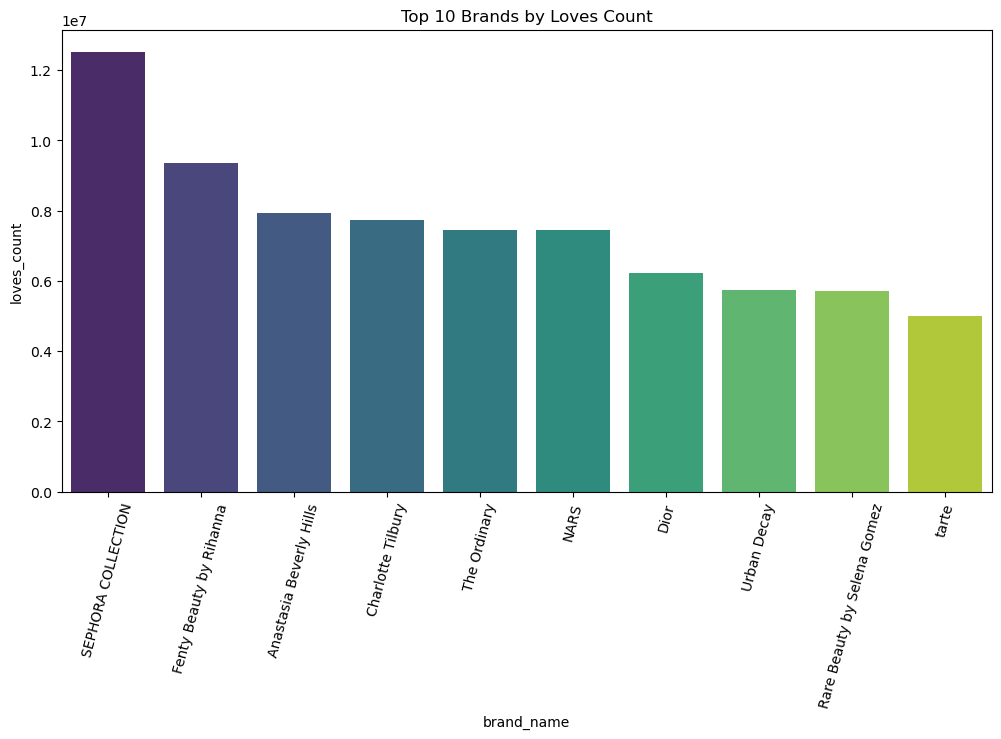

In [42]:
loves_count_per_brand = product_data.groupby('brand_name')['loves_count'].sum().reset_index()
loves_count_per_brand = loves_count_per_brand.sort_values(by='loves_count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=loves_count_per_brand.head(10), x='brand_name', y='loves_count', palette='viridis')
plt.title('Top 10 Brands by Loves Count')
plt.xticks(rotation=75)
plt.show()


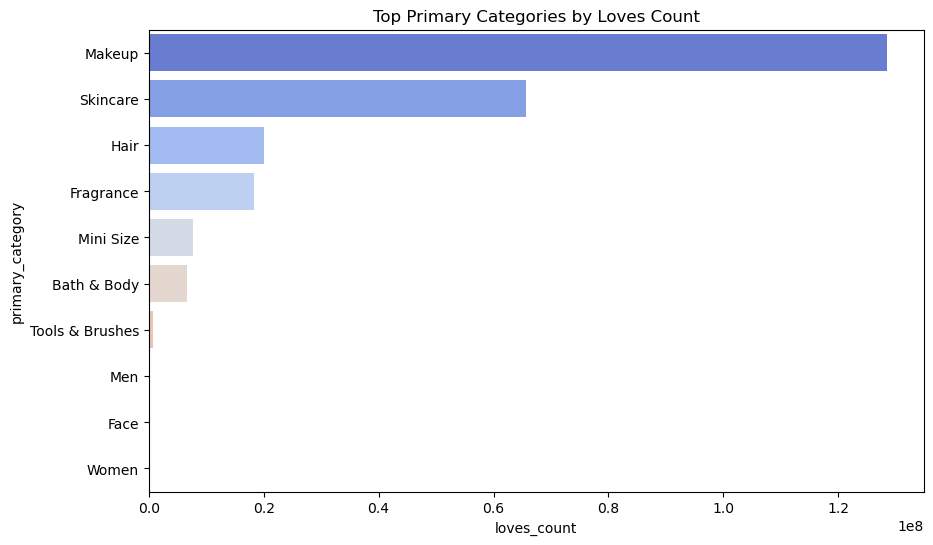

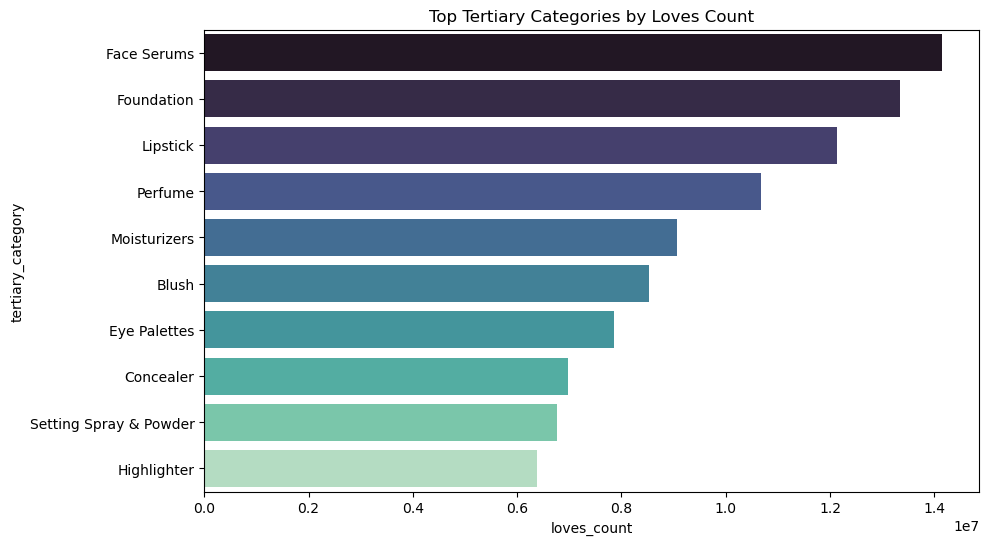

In [43]:
top_primary_categories = product_data.groupby('primary_category')['loves_count'].sum().reset_index()
top_primary_categories = top_primary_categories.sort_values(by='loves_count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_primary_categories.head(10), y='primary_category', x='loves_count', palette='coolwarm')
plt.title('Top Primary Categories by Loves Count')
plt.show()

top_tertiary_categories = product_data.groupby('tertiary_category')['loves_count'].sum().reset_index()
top_tertiary_categories = top_tertiary_categories.sort_values(by='loves_count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_tertiary_categories.head(10), y='tertiary_category', x='loves_count', palette='mako')
plt.title('Top Tertiary Categories by Loves Count')
plt.show()


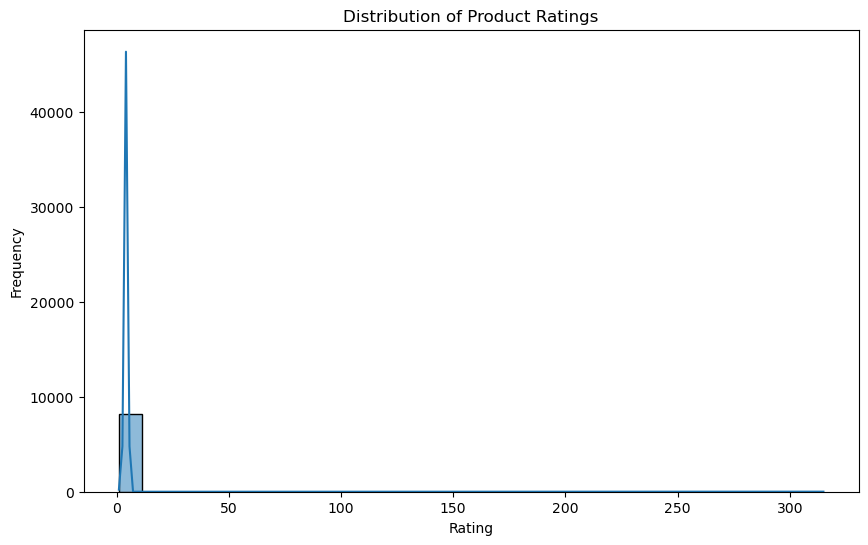

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(product_data['rating'], kde=True, bins=30)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


### There is a rating with 315, that seems a bit odd

In [54]:
product_data[product_data['rating'] == 315]

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
3828,P412535,MMMMâ?7070,Juliette Has a Gun,13506,4.2127,315.0,3.3 oz/ 100 mL,Size + Concentration + Formulation,3.3 oz/ 100 mL Eau de Parfum Spray,NaN,...,0,0,NaN,Fragrance,Women,Perfume,2,105,30.0,NaN


### Removing the above row for analysis of rating column

In [55]:
filtered_data = product_data[product_data['rating'] != 315]

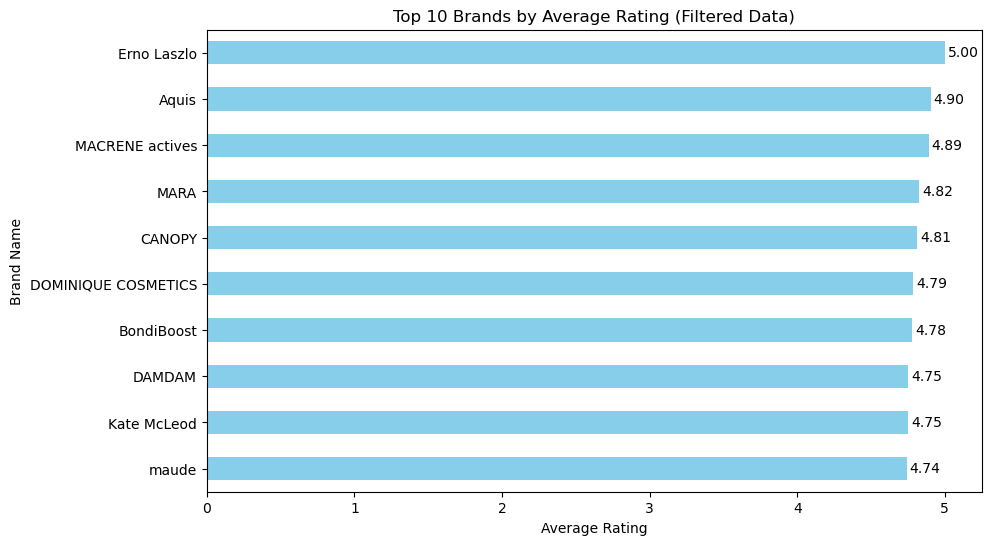

In [62]:
# Average rating per brand (Top 10)
avg_rating_by_brand_filtered = filtered_data.groupby('brand_name')['rating'].mean().sort_values(ascending=False)
top_10_brands_filtered = avg_rating_by_brand_filtered.head(10)

# Visualization: Top 10 Brands by Average Rating
plt.figure(figsize=(10, 6))
ax = top_10_brands_filtered.plot(kind='barh', color='skyblue')
plt.title('Top 10 Brands by Average Rating (Filtered Data)')
plt.xlabel('Average Rating')
plt.ylabel('Brand Name')
plt.gca().invert_yaxis()  # Highest rating on top
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, color='black')
plt.show()

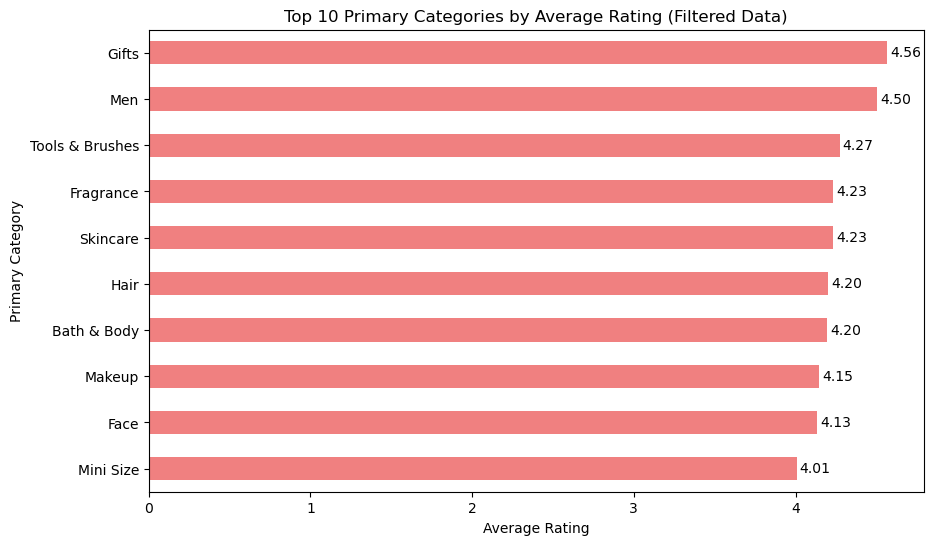

In [66]:
# Average rating per primary category (Top 10)
plt.figure(figsize=(10, 6))
ax = top_10_primary_filtered.plot(kind='barh', color='lightcoral')
plt.title('Top 10 Primary Categories by Average Rating (Filtered Data)')
plt.xlabel('Average Rating')
plt.ylabel('Primary Category')
plt.gca().invert_yaxis()

# Add rating labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, color='black')

plt.show()

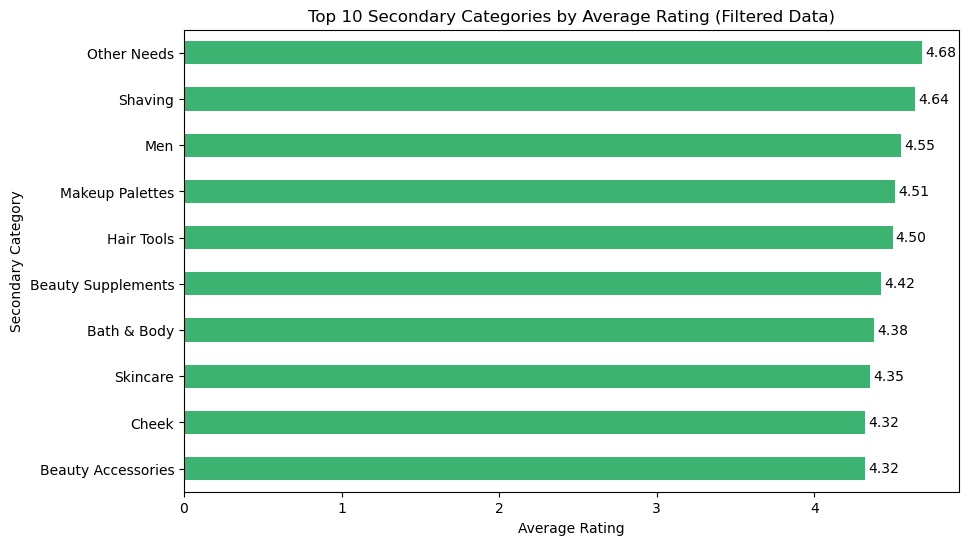

In [65]:
# Average rating per secondary category (Top 10)
avg_rating_by_secondary_filtered = filtered_data.groupby('secondary_category')['rating'].mean().sort_values(ascending=False)
top_10_secondary_filtered = avg_rating_by_secondary_filtered.head(10)

plt.figure(figsize=(10, 6))
ax = top_10_secondary_filtered.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Secondary Categories by Average Rating (Filtered Data)')
plt.xlabel('Average Rating')
plt.ylabel('Secondary Category')
plt.gca().invert_yaxis()
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, color='black')

plt.show()

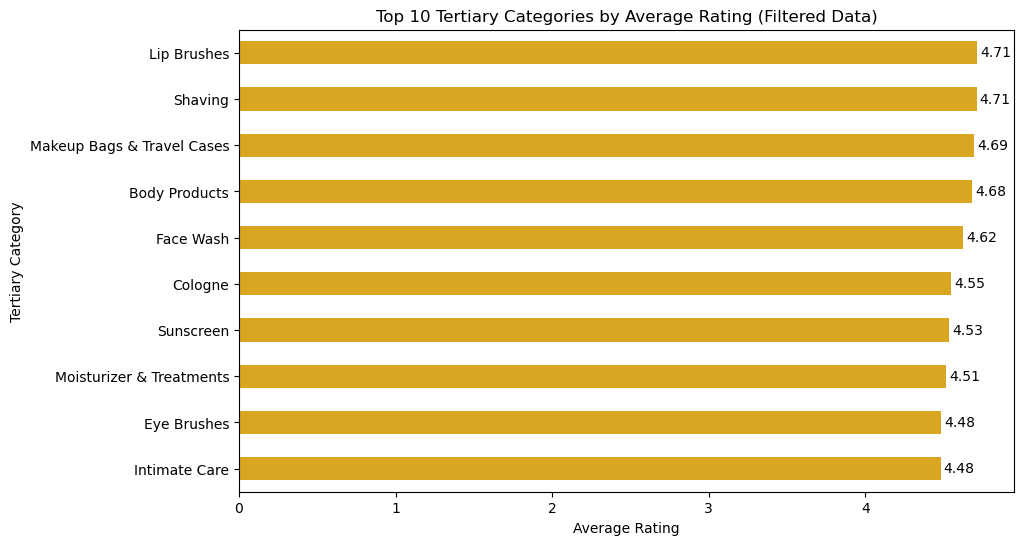

In [67]:
# Average rating per tertiary category (Top 10)
avg_rating_by_tertiary_filtered = filtered_data.groupby('tertiary_category')['rating'].mean().sort_values(ascending=False)
top_10_tertiary_filtered = avg_rating_by_tertiary_filtered.head(10)

plt.figure(figsize=(10, 6))
ax = top_10_tertiary_filtered.plot(kind='barh', color='goldenrod')
plt.title('Top 10 Tertiary Categories by Average Rating (Filtered Data)')
plt.xlabel('Average Rating')
plt.ylabel('Tertiary Category')
plt.gca().invert_yaxis()
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, color='black')
plt.show()

In [76]:
# Check if `value_price_usd` is always greater than or equal to `price_usd`
invalid_rows = product_data[
    product_data['value_price_usd'].notna() &  # Exclude rows where value_price_usd is null
    (product_data['value_price_usd'] < product_data['price_usd'])  # Check if value_price_usd < price_usd
]

# Output the result
if invalid_rows.empty:
    print("The condition 'value_price_usd >= price_usd' is always true (ignoring blanks).")
else:
    print("There are rows where 'value_price_usd < price_usd':")
    print(invalid_rows[['product_name', 'brand_name', 'value_price_usd', 'price_usd','sale_price_usd', 'limited_edition']])


There are rows where 'value_price_usd < price_usd':
                                           product_name         brand_name  \
569        Gimme Brow+ Volumizing  Fiber Eyebrow Pencil  Benefit Cosmetics   
588   Mini Gimme Brow + Volumizing Fiber Eyebrow Pencil  Benefit Cosmetics   
1317                    Makeup Brush Cleaner Travel Set     Cinema Secrets   
2481                   Faceshot Vitamin Ampoules Refill            FaceGym   
5222                    Retinol Youth Renewal Value Duo              Murad   
5433                   Festive Petite Diffuser Trio Set      NEST New York   

      value_price_usd  price_usd  sale_price_usd  limited_edition  
569               0.0       25.0             NaN                0  
588               0.0       15.0             NaN                0  
1317             12.0       15.0             NaN                1  
2481             88.0       90.0             NaN                0  
5222             40.0      126.0             NaN             

### There are 6 rows of data where the value price is less than the actual price

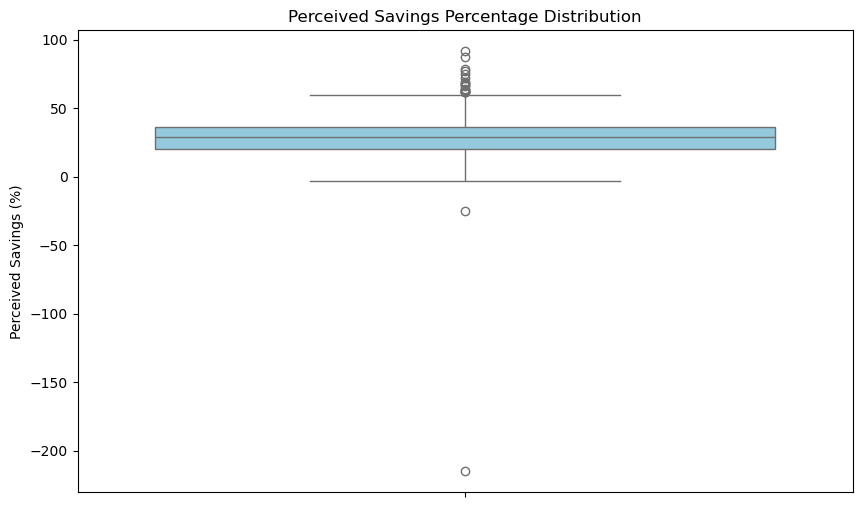

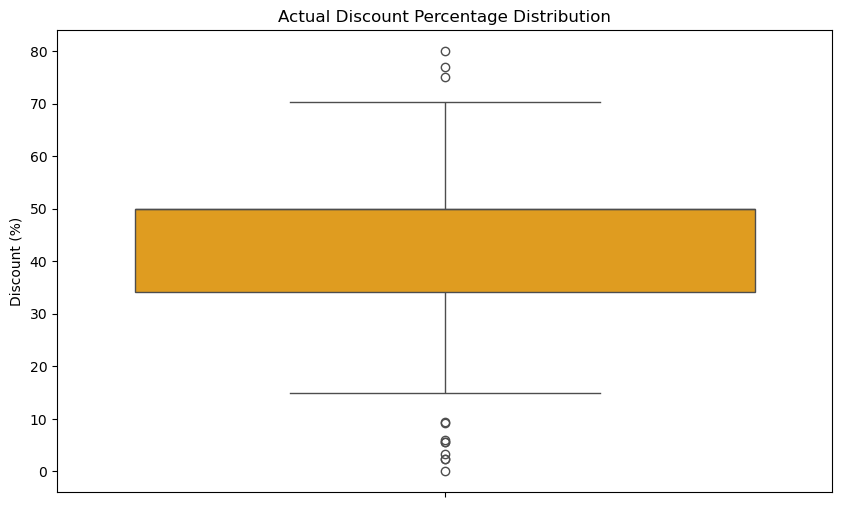

In [77]:
# Calculate perceived savings percentage
product_data['perceived_savings_pct'] = ((product_data['value_price_usd'] - product_data['price_usd']) / product_data['value_price_usd']) * 100

# Calculate actual discount percentage
product_data['discount_pct'] = ((product_data['price_usd'] - product_data['sale_price_usd']) / product_data['price_usd']) * 100

# Visualize perceived vs actual discounts
# Boxplot for perceived savings percentage
plt.figure(figsize=(10, 6))
sns.boxplot(data=product_data, y='perceived_savings_pct', color='skyblue')
plt.title('Perceived Savings Percentage Distribution')
plt.ylabel('Perceived Savings (%)')
plt.show()

# Boxplot for actual discount percentage
plt.figure(figsize=(10, 6))
sns.boxplot(data=product_data, y='discount_pct', color='orange')
plt.title('Actual Discount Percentage Distribution')
plt.ylabel('Discount (%)')
plt.show()


In [88]:
# Calculate percentage discount for each product
product_data['discount_pct'] = ((product_data['price_usd'] - product_data['sale_price_usd']) / product_data['price_usd']) * 100

# Handle cases where sale_price_usd is missing or zero to avoid division errors
product_data['discount_pct'] = product_data['discount_pct'].fillna(0).clip(lower=0)

# Sort products by discount percentage in descending order
sorted_discounts = product_data.sort_values(by='discount_pct', ascending=False)

# Select relevant columns for output
discounted_products = sorted_discounts[['product_name', 'brand_name', 'price_usd', 'sale_price_usd', 'discount_pct', 'limited_edition']]

# Display the top 10 products with the highest discount percentage
print(discounted_products.head(10))


                                      product_name          brand_name  \
6478               Cream Lip Shine Liquid Lipstick  SEPHORA COLLECTION   
499          BOUNCE Airbrush Liquid Whip Concealer       beautyblender   
6757           Double-Ended Textured Facial Roller  SEPHORA COLLECTION   
7736                               Maya Rollerball               TOCCA   
7735                                          Maya               TOCCA   
7732                          Giulietta Rollerball               TOCCA   
7730                                           Gia               TOCCA   
7739                                Gia Rollerball               TOCCA   
6471  Make No Mistake Foundation & Concealer Stick  SEPHORA COLLECTION   
6721                    Wishing You Eye Makeup Set  SEPHORA COLLECTION   

      price_usd  sale_price_usd  discount_pct  limited_edition  
6478       15.0             3.0     80.000000                0  
499        26.0             6.0     76.923077          

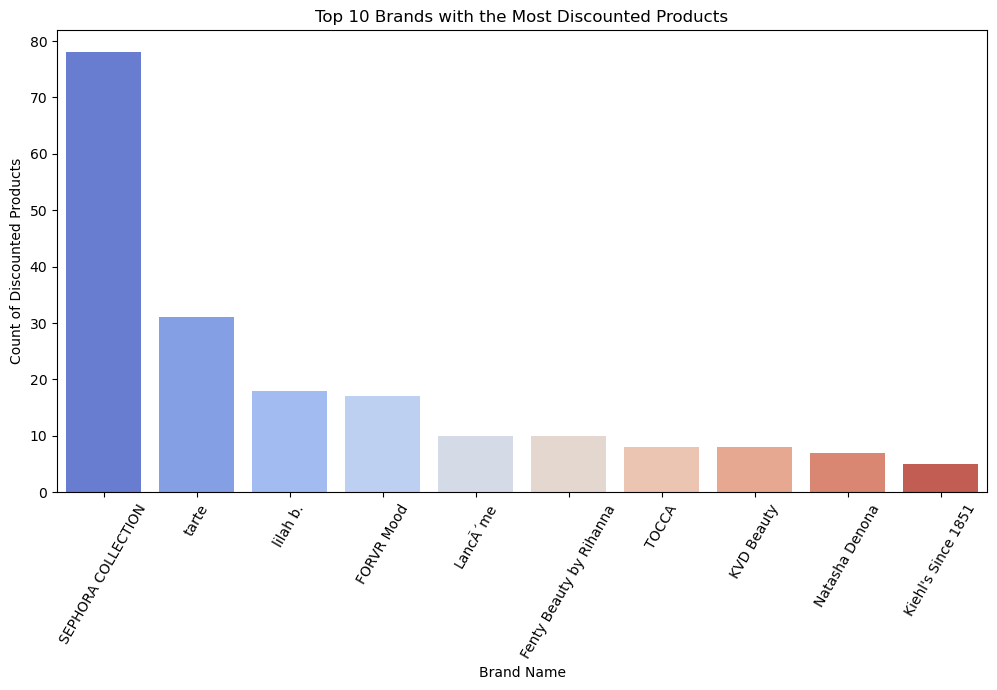

In [89]:
# Filter for products with a significant discount (e.g., greater than 0%)
discounted_products_filtered = discounted_products[discounted_products['discount_pct'] > 0]

# Count the number of discounted products per brand
brand_discount_counts = discounted_products_filtered['brand_name'].value_counts().reset_index()
brand_discount_counts.columns = ['brand_name', 'count']

# Plot the top 10 brands with the most discounted products
plt.figure(figsize=(12, 6))
sns.barplot(data=brand_discount_counts.head(10), x='brand_name', y='count', palette='coolwarm')
plt.title('Top 10 Brands with the Most Discounted Products')
plt.xlabel('Brand Name')
plt.ylabel('Count of Discounted Products')
plt.xticks(rotation=60)
plt.show()

In [90]:
# Filter for discounted products with a significant discount (e.g., >0%)
discounted_products_filtered = discounted_products[discounted_products['discount_pct'] > 0]

# Further filter for limited edition products
limited_edition_discounted = discounted_products_filtered[discounted_products_filtered['limited_edition'] == True]

# Select relevant columns for output
limited_edition_discounted_products = limited_edition_discounted[['product_name', 'brand_name', 'price_usd', 'sale_price_usd', 'discount_pct', 'limited_edition']]

# Display the products that are discounted and also limited edition
print(limited_edition_discounted_products)

# Optional: Count of such products
count_limited_edition_discounted = limited_edition_discounted_products.shape[0]
print(f"Number of discounted limited edition products: {count_limited_edition_discounted}")

                                           product_name           brand_name  \
6721                         Wishing You Eye Makeup Set   SEPHORA COLLECTION   
4278  Kitten Mini: Purrfect Cat Eyes Mini Mascara & ...           KVD Beauty   
6655               Wishing You 12 Pan Eyeshadow Palette   SEPHORA COLLECTION   
6642                    Winter Wonderland Eye Brush Set   SEPHORA COLLECTION   
6719                                 Lip Gloss Ornament   SEPHORA COLLECTION   
...                                                 ...                  ...   
1047                  Party Wave Mascara & Eyeliner Set              caliray   
3744                         Christmas Cracker Gift Set     Jo Malone London   
3727                                Mini Essentials Set     Jo Malone London   
8424  The Youth Vault: 13-Piece Vegan Skincare + App...  Youth To The People   
6989                                  Fall Cashmere Set               SKYLAR   

      price_usd  sale_price_usd  discou